In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [14]:
class CBNN:
    def __init__(self, x_train: list, targets: list, n_iter: int, n_hidden: int, lr: float = 0.1, n_batches: int = 5):
        """
        Initializes the neural network with training data and basic parameters.
        
        Parameters:
        - x_train (list): Input data for training.
        - targets (list): Target values (one-hot encoded).
        - n_iter (int): Number of training iterations (epochs).
        - n_hidden (int): Number of neurons in the hidden layer.
        - lr (float): Learning rate.
        - n_batches (int): Number of class-balanced batches to create.
        """
        self.x_train = np.array(x_train)
        self.targets = np.array(targets)
        self.n_iter = n_iter 
        self.hidden_layers = n_hidden
        self.lr = lr
        self.n_batches = n_batches
        self.loss_history = []  # Track loss over epochs
        
        # Store original labels for class-balanced batching (convert one-hot back to indices)
        self.y_labels = np.argmax(self.targets, axis=1)
        
        self.initializeWeightsBias(n_hidden)
        
        # Initialize 5 separate sets of weights and biases for each batch
        self.initializeBatchParameters(n_hidden)

        # Create class-balanced batches once
        self.batch_data, self.batch_targets = self.createClassBalancedBatches()

    def initializeWeightsBias(self, n_hidden: int) -> None:
        """Initialize main weights and biases (used for averaging)."""
        input_size = self.x_train.shape[1]
        output_size = self.targets.shape[1]
        
        # Main parameters (will store the averaged values)
        self.ws1 = np.random.randn(n_hidden, input_size) * np.sqrt(2. / input_size)
        self.bs1 = np.zeros([1, n_hidden])
        self.ws2 = np.random.randn(output_size, n_hidden) * np.sqrt(2. / n_hidden)
        self.bs2 = np.zeros([1, output_size])

    def initializeBatchParameters(self, n_hidden: int) -> None:
        """Initialize separate parameters for each of the 5 batches."""
        input_size = self.x_train.shape[1]
        output_size = self.targets.shape[1]
        
        # Create 5 sets of parameters: ws1_b1, ws1_b2, ..., ws1_b5, etc.
        self.batch_params = []
        
        for i in range(self.n_batches):
            params = {
                'ws1': np.random.randn(n_hidden, input_size) * np.sqrt(2. / input_size),
                'bs1': np.zeros([1, n_hidden]),
                'ws2': np.random.randn(output_size, n_hidden) * np.sqrt(2. / n_hidden),
                'bs2': np.zeros([1, output_size])
            }
            self.batch_params.append(params)
    
    def createClassBalancedBatches(self):
        """
        Creates n_batches class-balanced batches.
        Each batch contains equal number of samples from each class.
        """
        n_classes = self.targets.shape[1]
        samples_per_class_per_batch = self.x_train.shape[0] // (self.n_batches * n_classes)
        
        batch_data = []
        batch_targets = []
        
        # Group indices by class
        class_indices = [np.where(self.y_labels == c)[0] for c in range(n_classes)]
        
        # Shuffle each class's indices
        for indices in class_indices:
            np.random.shuffle(indices)
        
        # Create balanced batches
        for b in range(self.n_batches):
            batch_indices = []
            for c in range(n_classes):
                start_idx = b * samples_per_class_per_batch
                end_idx = (b + 1) * samples_per_class_per_batch
                # Handle case where we might run out of samples
                if end_idx > len(class_indices[c]):
                    end_idx = len(class_indices[c])
                batch_indices.extend(class_indices[c][start_idx:end_idx])
            
            # Shuffle the batch indices
            batch_indices = np.array(batch_indices)
            np.random.shuffle(batch_indices)
            
            batch_data.append(self.x_train[batch_indices])
            batch_targets.append(self.targets[batch_indices])
        
        return batch_data, batch_targets

    def f(self, x: np.ndarray, ws: np.ndarray, bs: np.ndarray) -> np.ndarray:
        """Performs the weighted sum of a perceptron."""
        z = x.dot(ws.T) + bs
        return z

    def relu(self, x):
        return np.where(x >= 0, x, 0)

    def gradiente_relu(self, x):
        return np.where(x >= 0, 1, 0)

    def softmax(self, z):
        z -= np.max(z, axis=1, keepdims=True)
        s = np.sum(np.exp(z), axis=1)
        return np.exp(z) / s[:, np.newaxis]

    def log_loss(self, y, p):
        # Clip to avoid log(0)
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -y * np.log(p) - (1 - y) * np.log(1 - p)
    
    def cross_entropy(self, y, p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -np.sum(y * np.log(p)) / y.shape[0]

    def predict(self, x: np.ndarray) -> np.ndarray:
        """Predicts using the averaged (main) parameters."""
        z1 = self.f(x, self.ws1, self.bs1)
        act1 = self.relu(z1)
        z2 = self.f(act1, self.ws2, self.bs2)
        act2 = self.softmax(z2)
        return act2


    def trainBatch(self, x_batch, y_batch, params):
        """Trains on a single batch using specific parameters."""
        total_loss = 0
        m = x_batch.shape[0]
        
        # Create copies to update
        ws1 = params['ws1'].copy()
        bs1 = params['bs1'].copy()
        ws2 = params['ws2'].copy()
        bs2 = params['bs2'].copy()
        
        # Forward pass
        z1 = self.f(x_batch, ws1, bs1)
        act1 = self.relu(z1)
        z2 = self.f(act1, ws2, bs2)
        act2 = self.softmax(z2)
        
        # Loss
        cost = self.cross_entropy(y_batch, act2)
        #cost = self.log_loss(y_batch, act2)
        total_loss += np.sum(cost)
        
        # Backward pass
        z_d_2 = act2 - y_batch
        w_d_2 = act1.T.dot(z_d_2)
        b_d_2 = np.sum(z_d_2, axis=0, keepdims=True)
        
        ws2 -= self.lr * w_d_2.T / m
        bs2 -= self.lr * b_d_2 / m
        
        cost_l1 = z_d_2.dot(ws2) * self.gradiente_relu(z1)
        w_d_1 = cost_l1.T.dot(x_batch)
        b_d_1 = np.sum(cost_l1, axis=0, keepdims=True)
        
        ws1 -= self.lr * w_d_1 / m
        bs1 -= self.lr * b_d_1 / m
    
        # Update params dictionary
        params['ws1'] = ws1
        params['bs1'] = bs1
        params['ws2'] = ws2
        params['bs2'] = bs2
        
        return total_loss

    def averageParameters(self):
        """Averages the parameters from all 5 batches into the main parameters."""
        # Initialize accumulators
        avg_ws1 = np.zeros_like(self.ws1)
        avg_bs1 = np.zeros_like(self.bs1)
        avg_ws2 = np.zeros_like(self.ws2)
        avg_bs2 = np.zeros_like(self.bs2)
        
        # Sum all batch parameters
        for params in self.batch_params:
            avg_ws1 += params['ws1']
            avg_bs1 += params['bs1']
            avg_ws2 += params['ws2']
            avg_bs2 += params['bs2']
        
        # Average
        self.ws1 = avg_ws1 / self.n_batches
        self.bs1 = avg_bs1 / self.n_batches
        self.ws2 = avg_ws2 / self.n_batches
        self.bs2 = avg_bs2 / self.n_batches
        
        # Copy averaged parameters back to each batch for next iteration
        for params in self.batch_params:
            params['ws1'] = self.ws1.copy()
            params['bs1'] = self.bs1.copy()
            params['ws2'] = self.ws2.copy()
            params['bs2'] = self.bs2.copy()

In [15]:
class RN_DIEGO(CBNN):

    def training(self):
        """Training with class-balanced batches and parameter averaging."""
        # Create class-balanced batches once
        batch_data, batch_targets = self.batch_data, self.batch_targets
        
        for epoch in range(self.n_iter):
            epoch_losses = []
            
            # Train each of the 5 batches with their own parameters
            for b in range(self.n_batches):
                loss = self.trainBatch(
                    batch_data[b], 
                    batch_targets[b], 
                    self.batch_params[b]
                )
                epoch_losses.append(loss)
            
            # Average all parameters across the 5 batches
            self.averageParameters()
            
            avg_loss = np.mean(epoch_losses)
            self.loss_history.append(avg_loss)
            #print(f'Epoch {epoch} - Avg Loss: {avg_loss:.4f}')

class RN_ARNOVI(CBNN):
    def training(self):
        """Training with class-balanced batches and parameter averaging."""
        # Create class-balanced batches once
        batch_data, batch_targets = self.batch_data, self.batch_targets
        
        for epoch in range(self.n_iter):
            epoch_losses = []
            
            # Train each of the 5 batches with their own parameters
            for b in range(self.n_batches):
                loss = self.trainBatch(
                    batch_data[b], 
                    batch_targets[b], 
                    self.batch_params[b]
                )
                epoch_losses.append(loss)
            
            
            avg_loss = np.mean(epoch_losses)
            self.loss_history.append(avg_loss)
            #print(f'Epoch {epoch} - Avg Loss: {avg_loss:.4f}')

        self.averageParameters()


LOADING MNIST
Downloading/loading MNIST dataset...
Data loaded: (70000, 784), Targets: (70000, 10)

========== RN_DIEGO ==========

Training block: 0 → 25
Accuracy after 25 epochs: 0.5833

Training block: 25 → 50
Accuracy after 50 epochs: 0.7191

Training block: 50 → 75
Accuracy after 75 epochs: 0.7797

Training block: 75 → 100
Accuracy after 100 epochs: 0.8160

Training block: 100 → 125
Accuracy after 125 epochs: 0.8367

Training block: 125 → 150
Accuracy after 150 epochs: 0.8518

Training block: 150 → 175
Accuracy after 175 epochs: 0.8620

Training block: 175 → 200
Accuracy after 200 epochs: 0.8695

Training block: 200 → 225
Accuracy after 225 epochs: 0.8753

Training block: 225 → 250
Accuracy after 250 epochs: 0.8801

Training block: 250 → 275
Accuracy after 275 epochs: 0.8844

Training block: 275 → 300
Accuracy after 300 epochs: 0.8876

Training block: 300 → 325
Accuracy after 325 epochs: 0.8903

Training block: 325 → 350
Accuracy after 350 epochs: 0.8928

Training block: 350 → 375

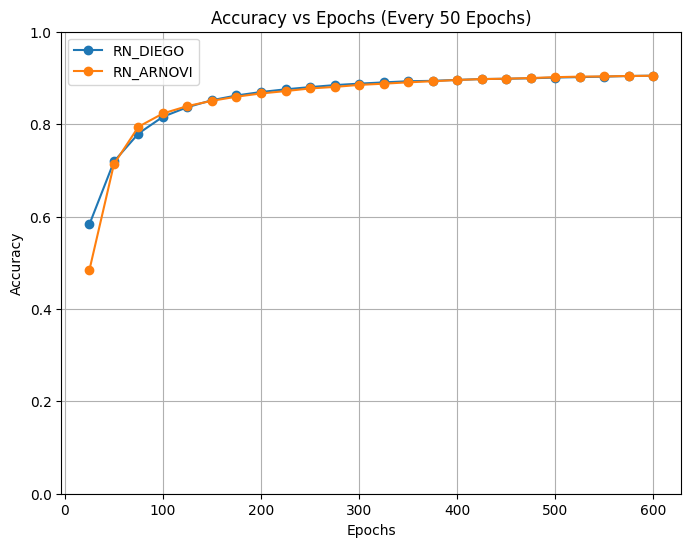

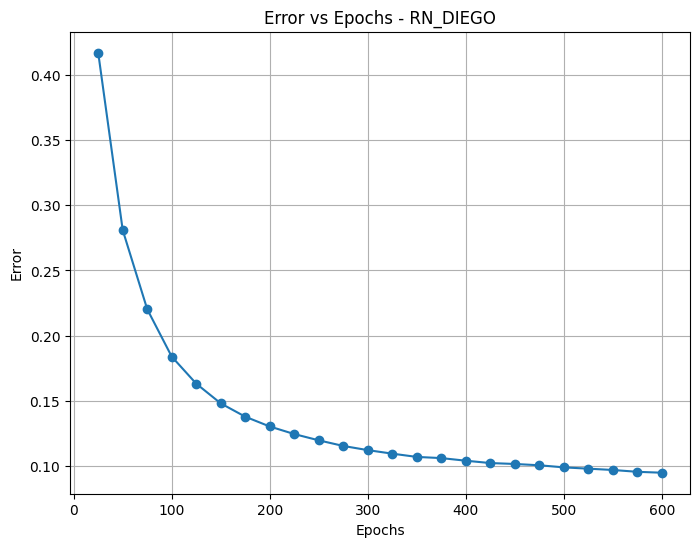

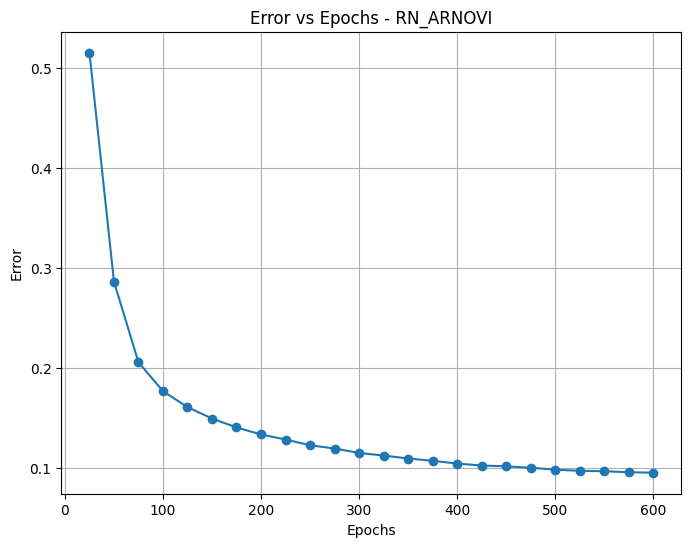

In [16]:
# LOAD MNIST #
def load_mnist(): 
    print("Downloading/loading MNIST dataset...") 
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser='auto') 
    X = mnist.data.astype(np.float32) / 255.0 
    y = mnist.target.astype(np.int32)
    
    def to_categorical(labels, num_classes=10): 
        one_hot = np.zeros((labels.size, num_classes)) 
        one_hot[np.arange(labels.size), labels] = 1 
        return one_hot 
    
    targets = to_categorical(y, 10)
        
    print(f"Data loaded: {X.shape}, Targets: {targets.shape}") 
    
    return X, targets

def evaluate_accuracy(model, x_test, y_test):

    predictions = model.predict(x_test)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(y_test, axis=1)

    return np.mean(predicted_labels == true_labels)

def train_in_blocks(model, x_test, y_test, total_epochs=900, block_size=50):

    epochs_done = 0
    accuracies = []
    epoch_points = []

    while epochs_done < total_epochs:

        print(f"\nTraining block: {epochs_done} → {epochs_done + block_size}")

        model.training()  # ejecuta 50 épocas (definidas en el constructor)

        epochs_done += block_size

        acc = evaluate_accuracy(model, x_test, y_test)

        accuracies.append(acc)
        epoch_points.append(epochs_done)

        print(f"Accuracy after {epochs_done} epochs: {acc:.4f}")

    return epoch_points, accuracies

def compare_models_progressive(n_epochs=300, n_hidden=50, lr=0.05, n_batches=5, n_iter=50):

    print("="*60)
    print("LOADING MNIST")
    print("="*60)

    X, Y = load_mnist()

    n_train = 60000
    n_test = 10000

    x_train = X[:n_train]
    y_train = Y[:n_train]
    x_test = X[n_train:n_train+n_test]
    y_test = Y[n_train:n_train+n_test]

    # ======================================
    # RN_DIEGO
    # ======================================

    print("\n========== RN_DIEGO ==========")

    model_diego = RN_DIEGO(
        x_train=x_train,
        targets=y_train,
        n_iter=n_iter, 
        n_hidden=n_hidden,
        lr=lr,
        n_batches=n_batches
    )

    epochs_diego, acc_diego = train_in_blocks(
        model_diego,
        x_test,
        y_test,
        total_epochs=n_epochs,
        block_size=n_iter
    )

    # ======================================
    # RN_ARNOVI
    # ======================================

    print("\n========== RN_ARNOVI ==========")

    model_arnovi = RN_ARNOVI(
        x_train=x_train,
        targets=y_train,
        n_iter=n_iter, 
        n_hidden=n_hidden,
        lr=lr,
        n_batches=n_batches
    )

    epochs_arnovi, acc_arnovi = train_in_blocks(
        model_arnovi,
        x_test,
        y_test,
        total_epochs=n_epochs,
        block_size=n_iter
    )

    # ============================================
    # 🔵 Precisión superpuesta
    # ============================================

    plt.figure(figsize=(8,6))

    plt.plot(epochs_diego, acc_diego, marker='o', label="RN_DIEGO")
    plt.plot(epochs_arnovi, acc_arnovi, marker='o', label="RN_ARNOVI")

    plt.title("Accuracy vs Epochs (Every 50 Epochs)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.ylim(0,1)
    plt.grid(True)
    plt.legend()
    plt.show()

    # ============================================
    # 🔴 Error RN_DIEGO
    # ============================================

    error_diego = [1 - a for a in acc_diego]

    plt.figure(figsize=(8,6))
    plt.plot(epochs_diego, error_diego, marker='o')
    plt.title("Error vs Epochs - RN_DIEGO")
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.grid(True)
    plt.show()

    # ============================================
    # 🔴 Error RN_ARNOVI
    # ============================================

    error_arnovi = [1 - a for a in acc_arnovi]

    plt.figure(figsize=(8,6))
    plt.plot(epochs_arnovi, error_arnovi, marker='o')
    plt.title("Error vs Epochs - RN_ARNOVI")
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":

    compare_models_progressive(
        n_epochs=600,
        n_hidden=50,
        lr=0.05,
        n_batches=5,
        n_iter=25
    )
    